# 06 · Advanced univariate vignettes

Three distinct questions: threshold exceedances at Big Bear, latent Normal
populations, and competing or mixed flood-generating processes. Each case
below keeps its saved input row, model family and sampler design. Restart
Kernel and Run All builds and runs all seven top-level cases and the four
child fits required by the two composites.

In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from time import perf_counter
from math import erf, isclose, sqrt
import pandas as pd
from IPython.display import display
from bestfit_examples.runtime import load_bestfit
from bestfit_examples.raw import load_raw
from bestfit_examples.fresh import plot_context, plots, show, record_run
runtime = load_bestfit()
print(runtime)
from System import Array, Double, DateTime
from System.Collections.Generic import List
from Numerics.Data import ProbabilityOrdinates, TimeBlockWindow
from Numerics.Data.Statistics import Probability
from Numerics.Distributions import UnivariateDistributionType
from RMC.BestFit.Models import (DataFrame, ExactData, ExactSeries, IntervalData,
                                ThresholdData, UnivariateDistribution, PointProcessModel, MixtureModel)
from RMC.BestFit.Analyses import (UnivariateAnalysis, PointProcessAnalysis, MixtureAnalysis,
                                  CompositeAnalysis, WeightedUnivariateAnalysis,
                                  CompositeType, AverageMethod)
from RMC.BestFit.Estimation import BayesianAnalysis

{'schemaVersion': 1, 'sourceCommit': 'db5807d6e3a85606797cda79542f2d51a80a57a6', 'numericsVersion': '2.2.0.0', 'bestFitVersion': '2.0.0.0', 'targetFramework': '.NETCoreApp,Version=v10.0', 'fileHashes': {'RMC.BestFit.dll': '8714d7e4e9d738e99e45c36d5581ce759e8fd535361b7a141d9647a9a5eac8dd', 'Numerics.dll': '364d2296a6024643a8bf0f60d1eaa8f5be5511563dea0b5d572074e45c27ea48'}}


## The three source projects and their separate observations

Big Bear POT has 253 dated events in 67 observation years at a 1-inch
threshold; the AMS comparison has 67 annual values. Synthetic Normal
mixtures use separate 100-observation inputs, including exact zeros for
the inflated case. Composite children each have their own LogNormal input.

In [3]:
pot_raw = load_raw("point-process-examples")
mix_raw = load_raw("mixture-distribution-examples")
flood_raw = load_raw("mixed-population-examples")
pot_inputs = ["USC00040741 - POT", "USC00040741 - AMS"]
mixture_inputs = ["Mixture of 2 Normals - Data",
                  "Mixture of 2 Normals and Zero Inflated - Data"]
flood_inputs = ["Full POR - Snow Driven Floods", "Full POR - Rainfall Driven Floods",
                "AMS Sub-Sample - Snow Driven Floods", "AMS Sub-Sample - Rain Driven Floods",
                "Full POR - Annual Max Series", "AMS Mixture of Flood Types"]
display(pd.DataFrame(pot_raw["inputs"][pot_inputs[0]]["series"]["ExactSeries"]).head())

,DateTime,Index,IsLowOutlier,Value
0,1960-11-06T00:00:00.0000000,1960,False,1.4409448818897639
1,1961-01-26T00:00:00.0000000,1961,False,1.2913385826771653
2,1961-03-15T00:00:00.0000000,1961,False,1.1614173228346456
3,1961-11-20T00:00:00.0000000,1961,False,1.0984251968503937
4,1961-12-02T00:00:00.0000000,1961,False,2.9881889763779528


## Construct all input frames from observed records

Dated POT records retain their days for season membership. Exact zeros
remain zeros in the mixture input; the probability atom is inferred from
their frequency. No saved model or posterior state is loaded.

In [4]:
frames = {}
for source, input_names in ((pot_raw, pot_inputs), (mix_raw, mixture_inputs),
                            (flood_raw, flood_inputs)):
    for input_name in input_names:
        observed = source["inputs"][input_name]
        frame = DataFrame()
        frame.ExactSeries = ExactSeries()
        for row in observed["series"]["ExactSeries"]:
            point = ExactData(DateTime.Parse(row["DateTime"]), float(row["Value"]))
            point.Index = int(row["Index"])
            point.IsLowOutlier = row.get("IsLowOutlier", "False") == "True"
            frame.ExactSeries.Add(point)
        for row in observed["series"]["IntervalSeries"]:
            frame.IntervalSeries.Add(IntervalData(int(row["Index"]), float(row["LowerValue"]),
                                                 float(row["Value"]), float(row["UpperValue"])))
        for row in observed["series"]["ThresholdSeries"]:
            threshold = ThresholdData(int(row["StartIndex"]), int(row["EndIndex"]), float(row["Value"]))
            threshold.NumberAbove = int(row["NumberAbove"])
            frame.ThresholdSeries.Add(threshold)
        frame.PlottingParameter = float(observed["attributes"]["PlottingParameter"])
        frame.CalculatePlottingPositions()
        frames[input_name] = frame
display(pd.DataFrame([{"Input": name, "Exact": frame.ExactSeries.Count}
                      for name, frame in frames.items()]))

,Input,Exact
0,USC00040741 - POT,253
1,USC00040741 - AMS,67
2,Mixture of 2 Normals - Data,100
3,Mixture of 2 Normals and Zero Inflated - Data,100
4,Full POR - Snow Driven Floods,100
5,Full POR - Rainfall Driven Floods,100
6,AMS Sub-Sample - Snow Driven Floods,74
7,AMS Sub-Sample - Rain Driven Floods,26
8,Full POR - Annual Max Series,100
9,AMS Mixture of Flood Types,100


## Point process and annual-maxima alternatives

The nonseasonal POT model uses an October water-year start. The seasonal
variant uses August and two GEV seasonal components. Both infer the 67-year
exposure from the original dated record. The AMS GEV is a separate fit.

In [5]:
aep = [1e-6, 2e-6, 5e-6, 1e-5, 2e-5, 5e-5, .0001, .0002, .0005,
       .001, .002, .005, .01, .02, .05, .1, .2, .3, .5, .7, .8, .9, .95, .98, .99]
analyses, models, timings = {}, {}, {}
for name, seasonal, start_month, chains, thinning, initial, jump in [
    ("USC00040741 - Point Process", False, 10, 6, 30, 300, .971630931303994),
    ("USC00040741 - Seasonal Point Process", True, 8, 16, 80, 800, .595)]:
    model = PointProcessModel()
    model.DataFrame = frames[pot_inputs[0]]
    model.IsSeasonal = seasonal
    model.TimeBlock = TimeBlockWindow.WaterYear
    model.StartMonth = start_month
    model.UseDefaults = True
    model.Threshold = 1.0
    assert abs(float(model.Threshold) - 1.0) < 1e-9
    assert abs(float(model.TotalYears) - 67.0) < 1e-9
    assert abs(float(model.Lambda) - 253.0 / 67.0) < 1e-12
    model.UseDefaultFlatPriors = True
    model.UseJeffreysRuleForScale = True
    analysis = PointProcessAnalysis(model)
    analysis.ProbabilityOrdinates = ProbabilityOrdinates(Array[Double](aep))
    settings = analysis.BayesianAnalysis
    settings.UseSimulationDefaults = True
    settings.Type = BayesianAnalysis.SamplerType.DEMCzs
    settings.NumberOfChains = chains
    settings.ThinningInterval = thinning
    settings.WarmupIterations = 1750
    settings.Iterations = 3500
    settings.PRNGSeed = 12345
    settings.UseAdvancedSimulationDefaults = True
    settings.InitialIterations = initial
    settings.Jump = jump
    settings.JumpThreshold = .1
    settings.SnookerThreshold = .1
    settings.Noise = 1e-12
    settings.Scale = 5.6644
    settings.Beta = .05
    settings.MaxTreeDepth = 10
    settings.CredibleIntervalWidth = .9
    settings.OutputLength = 10000
    settings.PointEstimator = BayesianAnalysis.PointEstimateType.PosteriorMean
    started = perf_counter()
    analysis.RunAsync(None).GetAwaiter().GetResult()
    timings[name] = perf_counter() - started
    analyses[name], models[name] = analysis, model
    record_run(name, analysis, timings[name], raw=pot_raw, model=model)

USC00040741 - Point Process: completed in 4.63 s. Execution alone does not establish convergence or scientific acceptance.


USC00040741 - Seasonal Point Process: completed in 13.10 s. Execution alone does not establish convergence or scientific acceptance.


In [6]:
gev_name = "USC00040741 - GEV"
gev_model = UnivariateDistribution(frames[pot_inputs[1]], UnivariateDistributionType.GeneralizedExtremeValue)
gev_model.UseDefaultFlatPriors = True
gev_model.UseJeffreysRuleForScale = True
gev = UnivariateAnalysis(gev_model)
gev.ProbabilityOrdinates = ProbabilityOrdinates(Array[Double](aep))
gev_settings = gev.BayesianAnalysis
gev_settings.UseSimulationDefaults = True
gev_settings.Type = BayesianAnalysis.SamplerType.DEMCzs
gev_settings.NumberOfChains = 6
gev_settings.ThinningInterval = 30
gev_settings.WarmupIterations = 1750
gev_settings.Iterations = 3500
gev_settings.PRNGSeed = 12345
gev_settings.UseAdvancedSimulationDefaults = True
gev_settings.InitialIterations = 300
gev_settings.Jump = .971630931303994
gev_settings.JumpThreshold = .1
gev_settings.SnookerThreshold = .1
gev_settings.Noise = 1e-12
gev_settings.Scale = 5.6644
gev_settings.Beta = .05
gev_settings.MaxTreeDepth = 10
gev_settings.CredibleIntervalWidth = .9
gev_settings.OutputLength = 10000
gev_settings.PointEstimator = BayesianAnalysis.PointEstimateType.PosteriorMean
started = perf_counter()
gev.RunAsync(None).GetAwaiter().GetResult()
timings[gev_name] = perf_counter() - started
analyses[gev_name], models[gev_name] = gev, gev_model
record_run(gev_name, gev, timings[gev_name], raw=pot_raw, model=gev_model)

USC00040741 - GEV: completed in 1.57 s. Execution alone does not establish convergence or scientific acceptance.


{'name': 'USC00040741 - GEV',
 'class': 'UnivariateAnalysis',
 'status': 'completed',
 'runId': 'fce94226-6f8b-48b8-9153-742d1b519e7e',
 'seconds': 1.573,
 'source': {'bytes': 17629184,
  'relative_path': 'examples/4-univariate-distribution-analysis/3-point-process-analysis/point-process-examples.bestfit',
  'repository_commit': '3fa55a0f75bbd583e2fb7fce42180faa376f007c',
  'sha256': '97cbda9e1747c6996af85ecadcf52a2ba02f28e0863c9d9e0d2c8305e1594514'},
 'runtime': {'schemaVersion': 1,
  'sourceCommit': 'db5807d6e3a85606797cda79542f2d51a80a57a6',
  'numericsVersion': '2.2.0.0',
  'bestFitVersion': '2.0.0.0',
  'targetFramework': '.NETCoreApp,Version=v10.0',
  'fileHashes': {'RMC.BestFit.dll': '8714d7e4e9d738e99e45c36d5581ce759e8fd535361b7a141d9647a9a5eac8dd',
   'Numerics.dll': '364d2296a6024643a8bf0f60d1eaa8f5be5511563dea0b5d572074e45c27ea48'}},
 'analysisSettings': '<UnivariateAnalysis IsEstimated="true">\r\n  <ProbabilityOrdinates>9.9999999999999995E-07|1.9999999999999999E-06|5.000000

## Normal mixtures, with and without a structural zero atom

These are controlled synthetic examples. The zero-inflated fit retains
exact zeros, and BestFit derives their probability mass from the input.
Mixing weights and component coordinates are estimated afresh.

In [7]:
mixture_cases = [
    ("Mixture Distribution - 2 Normals", mixture_inputs[0], False),
    ("Mixture Distribution - 2 Normals - Zero-Inflated", mixture_inputs[1], True),
]
normal_pair = List[UnivariateDistributionType]()
normal_pair.Add(UnivariateDistributionType.Normal)
normal_pair.Add(UnivariateDistributionType.Normal)
for name, input_name, inflated in mixture_cases:
    model = MixtureModel(frames[input_name], normal_pair, inflated)
    model.UseDefaultFlatPriors = True
    model.UseJeffreysRuleForScale = True
    assert bool(model.IsZeroInflated) == inflated
    if inflated:
        assert sum(float(row["Value"]) == 0.0 for row in
                   mix_raw["inputs"][input_name]["series"]["ExactSeries"]) == 10
        assert abs(float(model.Mixture.ZeroWeight) - .1) < 1e-9
    analysis = MixtureAnalysis(model)
    mixture_aep = aep[:20] + [.75, .8, .85] + aep[21:] if inflated else aep
    analysis.ProbabilityOrdinates = ProbabilityOrdinates(Array[Double](mixture_aep))
    settings = analysis.BayesianAnalysis
    settings.UseSimulationDefaults = True
    settings.Type = BayesianAnalysis.SamplerType.DEMCzs
    settings.NumberOfChains = 12
    settings.ThinningInterval = 60
    settings.WarmupIterations = 1750
    settings.Iterations = 3500
    settings.PRNGSeed = 12345
    settings.UseAdvancedSimulationDefaults = True
    settings.InitialIterations = 600
    settings.Jump = .6870468203356547
    settings.JumpThreshold = .1
    settings.SnookerThreshold = .1
    settings.Noise = 1e-12
    settings.Scale = 5.6644
    settings.Beta = .05
    settings.MaxTreeDepth = 10
    settings.CredibleIntervalWidth = .9
    settings.OutputLength = 10000
    settings.PointEstimator = BayesianAnalysis.PointEstimateType.PosteriorMean
    started = perf_counter()
    analysis.RunAsync(None).GetAwaiter().GetResult()
    timings[name] = perf_counter() - started
    analyses[name], models[name] = analysis, model
    record_run(name, analysis, timings[name], raw=mix_raw, model=model)

Mixture Distribution - 2 Normals: completed in 9.46 s. Execution alone does not establish convergence or scientific acceptance.


Mixture Distribution - 2 Normals - Zero-Inflated: completed in 11.62 s. Execution alone does not establish convergence or scientific acceptance.


## Fit four LogNormal flood-process children

The full-period snow/rain children belong to the competing-risks case.
The two AMS sub-samples belong to the mixture case. Their observation
periods are intentionally different and must not be pooled.

In [8]:
child_specs = [
    ("Full POR Snow Driven", flood_inputs[0]),
    ("Full POR Rainfall Driven", flood_inputs[1]),
    ("Sub-Sample - Snow Driven", flood_inputs[2]),
    ("Sub-Sample - Rain Driven", flood_inputs[3]),
]
for name, input_name in child_specs:
    model = UnivariateDistribution(frames[input_name], UnivariateDistributionType.LogNormal)
    model.UseDefaultFlatPriors = True
    model.UseJeffreysRuleForScale = True
    analysis = UnivariateAnalysis(model)
    analysis.ProbabilityOrdinates = ProbabilityOrdinates(Array[Double](aep))
    settings = analysis.BayesianAnalysis
    settings.UseSimulationDefaults = True
    settings.Type = BayesianAnalysis.SamplerType.DEMCzs
    settings.NumberOfChains = 4
    settings.ThinningInterval = 20
    settings.WarmupIterations = 1750
    settings.Iterations = 3500
    settings.PRNGSeed = 12345
    settings.UseAdvancedSimulationDefaults = True
    settings.InitialIterations = 200
    settings.Jump = 1.19
    settings.JumpThreshold = .1
    settings.SnookerThreshold = .1
    settings.Noise = 1e-12
    settings.Scale = 5.6644
    settings.Beta = .05
    settings.MaxTreeDepth = 10
    settings.CredibleIntervalWidth = .9
    settings.OutputLength = 10000
    settings.PointEstimator = BayesianAnalysis.PointEstimateType.PosteriorMean
    started = perf_counter()
    analysis.RunAsync(None).GetAwaiter().GetResult()
    timings[name] = perf_counter() - started
    analyses[name], models[name] = analysis, model
    record_run(name, analysis, timings[name], raw=flood_raw, model=model)

Full POR Snow Driven: completed in 1.13 s. Execution alone does not establish convergence or scientific acceptance.


Full POR Rainfall Driven: completed in 1.06 s. Execution alone does not establish convergence or scientific acceptance.


Sub-Sample - Snow Driven: completed in 0.84 s. Execution alone does not establish convergence or scientific acceptance.


Sub-Sample - Rain Driven: completed in 0.64 s. Execution alone does not establish convergence or scientific acceptance.


## Combine fitted processes two different ways

Competing risks models the annual maximum from independent flood types;
its saved zero child weights are not mixture weights. The mixture case
selects one of two flood populations with fixed .75/.25 weights.
CompositeAnalysis requires its child fits to have completed first.

In [9]:
composite_specs = [
    ("Competing Flood Types", CompositeType.CompetingRisks,
     [("Full POR Snow Driven", 0.0), ("Full POR Rainfall Driven", 0.0)],
     "Full POR - Annual Max Series"),
    ("Mixture of Flood Types", CompositeType.Mixture,
     [("Sub-Sample - Snow Driven", .75), ("Sub-Sample - Rain Driven", .25)],
     "AMS Mixture of Flood Types"),
]
for name, kind, child_weights, composite_input in composite_specs:
    children = List[WeightedUnivariateAnalysis]()
    for child_name, weight in child_weights:
        children.Add(WeightedUnivariateAnalysis(analyses[child_name], weight))
    analysis = CompositeAnalysis(children)
    analysis.CompositeDistributionType = kind
    analysis.ModelAverageMethod = AverageMethod.DIC
    analysis.Dependency = Probability.DependencyType.Independent
    analysis.IsMaximum = True
    analysis.ProbabilityOrdinates = ProbabilityOrdinates(Array[Double](aep))
    analysis.BayesianAnalysis.PRNGSeed = 12345
    analysis.BayesianAnalysis.OutputLength = 10000
    analysis.BayesianAnalysis.CredibleIntervalWidth = .9
    started = perf_counter()
    analysis.RunAsync(None).GetAwaiter().GetResult()
    timings[name] = perf_counter() - started
    analyses[name] = analysis
    record_run(name, analysis, timings[name], raw=flood_raw)

Competing Flood Types: completed in 1.12 s. Execution alone does not establish convergence or scientific acceptance.


Mixture of Flood Types: completed in 1.44 s. Execution alone does not establish convergence or scientific acceptance.


## Inspect fresh results

POT event rates and annual-maxima AEPs have different meanings. Likewise,
a latent Normal mixture and the structural flood composites answer different
questions. Compare curves within those contexts, not by cross-family AIC.

,Case,Class,Run seconds
0,USC00040741 - Point Process,PointProcessAnalysis,4.631686
1,USC00040741 - GEV,UnivariateAnalysis,1.573131
2,USC00040741 - Seasonal Point Process,PointProcessAnalysis,13.103392
3,Mixture Distribution - 2 Normals,MixtureAnalysis,9.457153
4,Mixture Distribution - 2 Normals - Zero-Inflated,MixtureAnalysis,11.616504
5,Competing Flood Types,CompositeAnalysis,1.120325
6,Mixture of Flood Types,CompositeAnalysis,1.441916


,Case,Parameter index,R-hat,ESS
0,USC00040741 - Point Process,0,0.999990,9583.358278
1,USC00040741 - Point Process,1,1.000558,9723.366837
2,USC00040741 - Point Process,2,1.000276,9818.328498
3,USC00040741 - GEV,0,1.000240,9025.608692
4,USC00040741 - GEV,1,1.000258,9175.469121
5,USC00040741 - GEV,2,1.001000,9575.215095
6,USC00040741 - Seasonal Point Process,0,1.000064,7804.619819
7,USC00040741 - Seasonal Point Process,1,1.000202,6006.899664
8,USC00040741 - Seasonal Point Process,2,1.000024,8394.951931
9,USC00040741 - Seasonal Point Process,3,1.000561,8580.624497


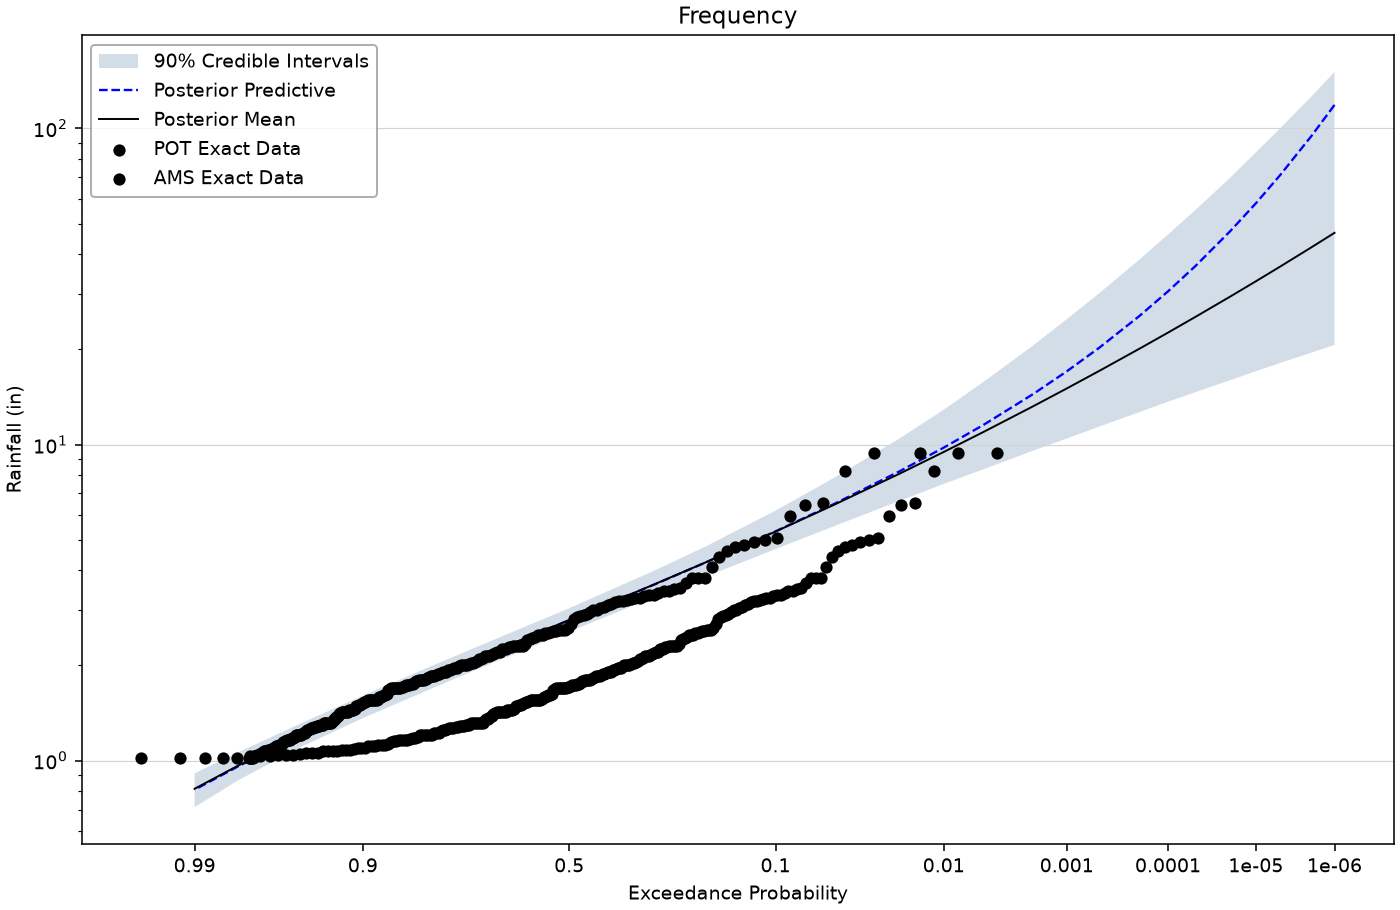

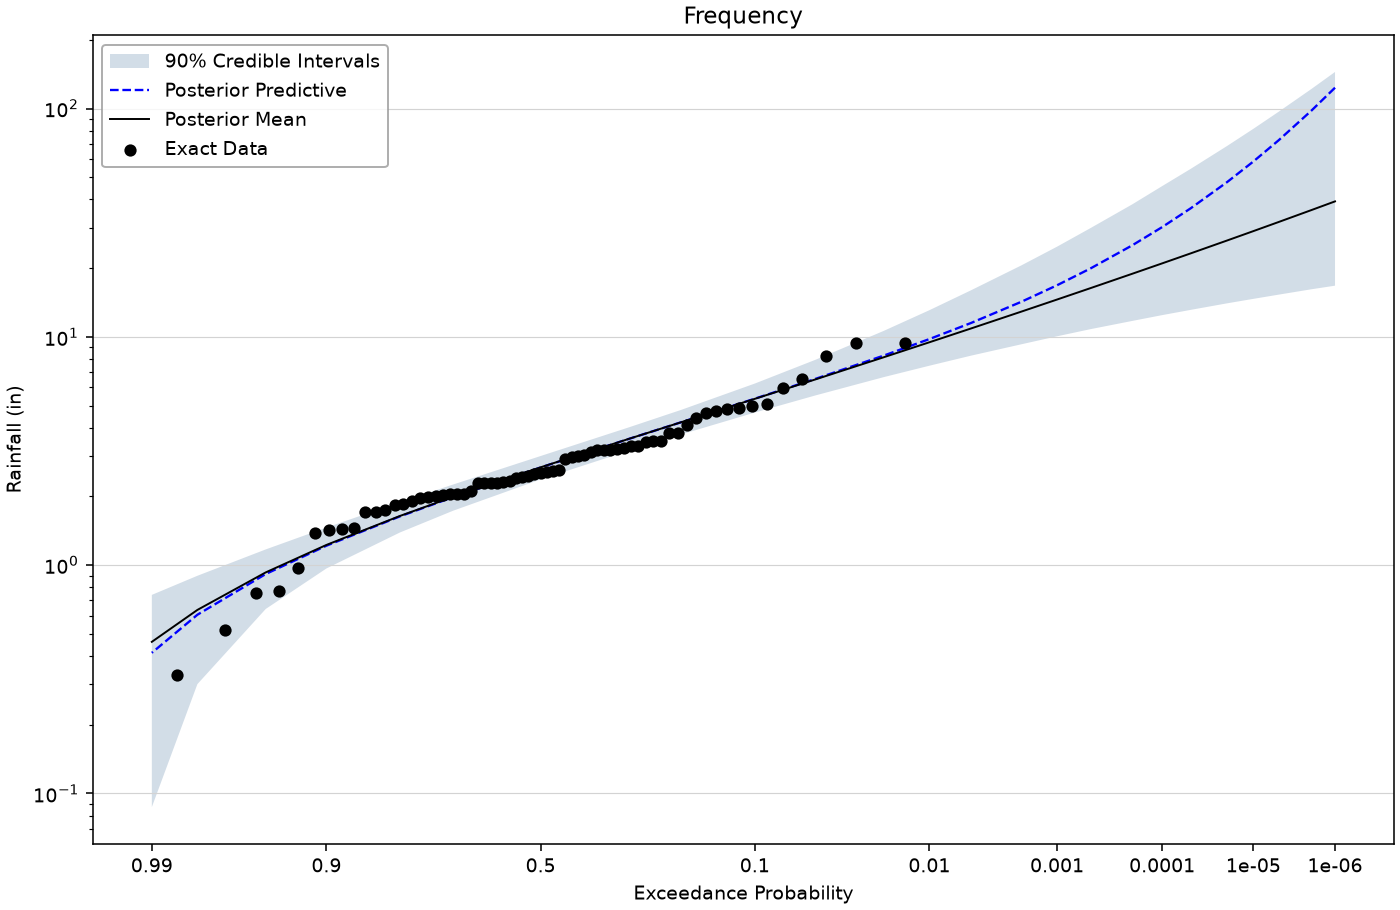

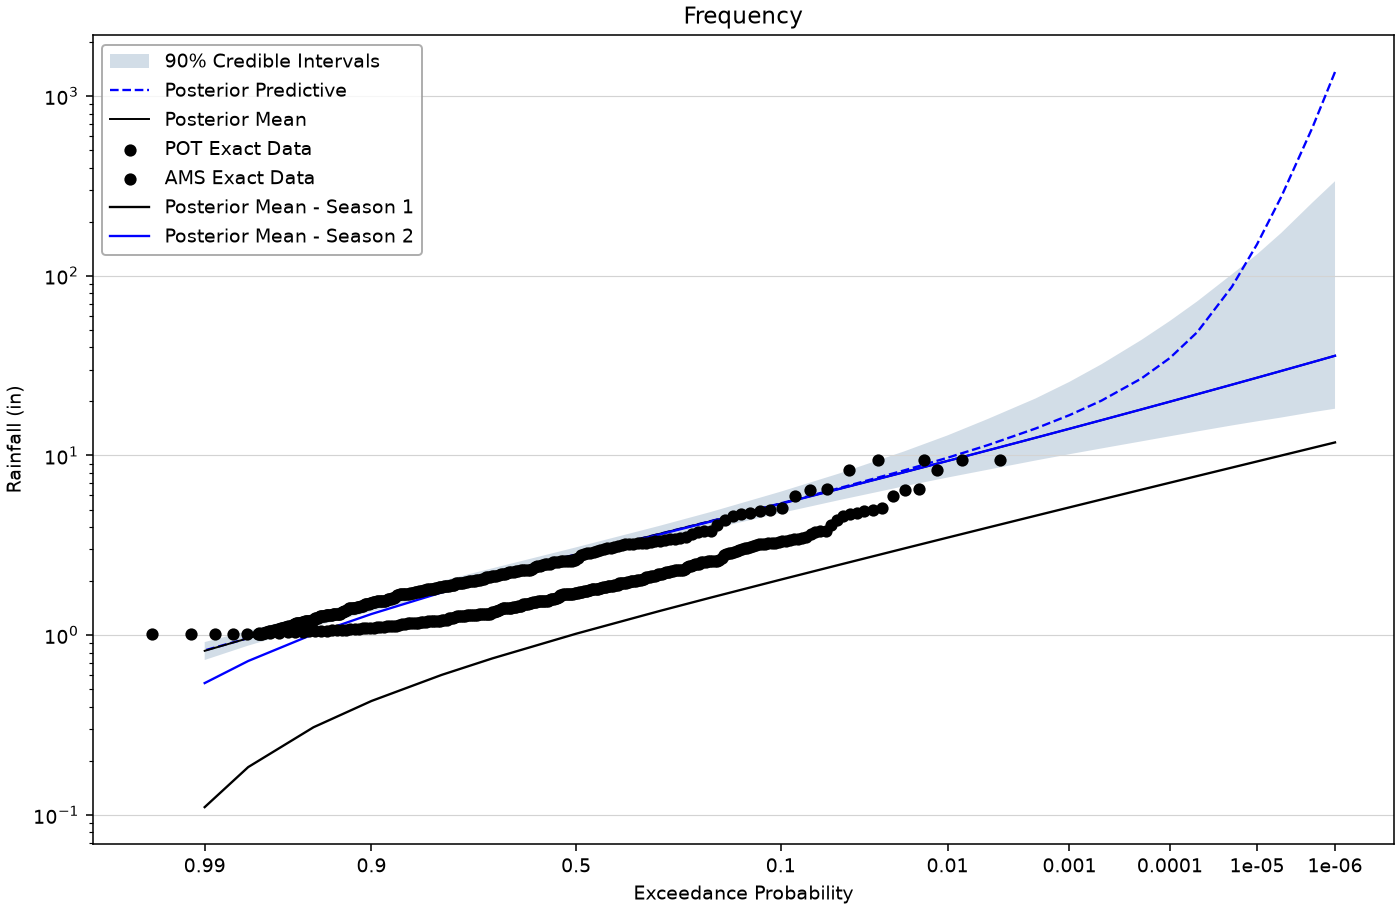

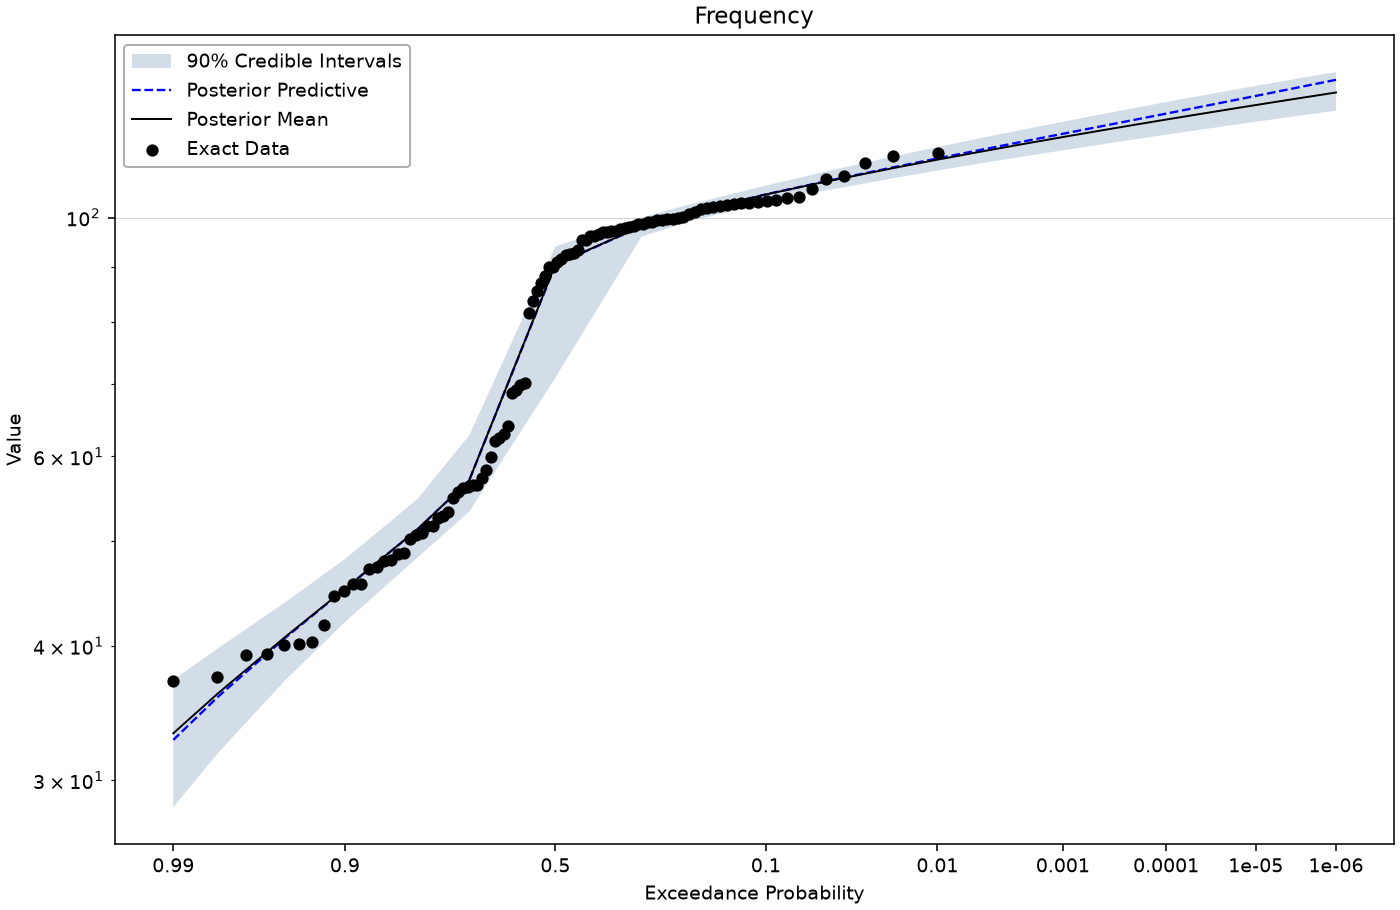

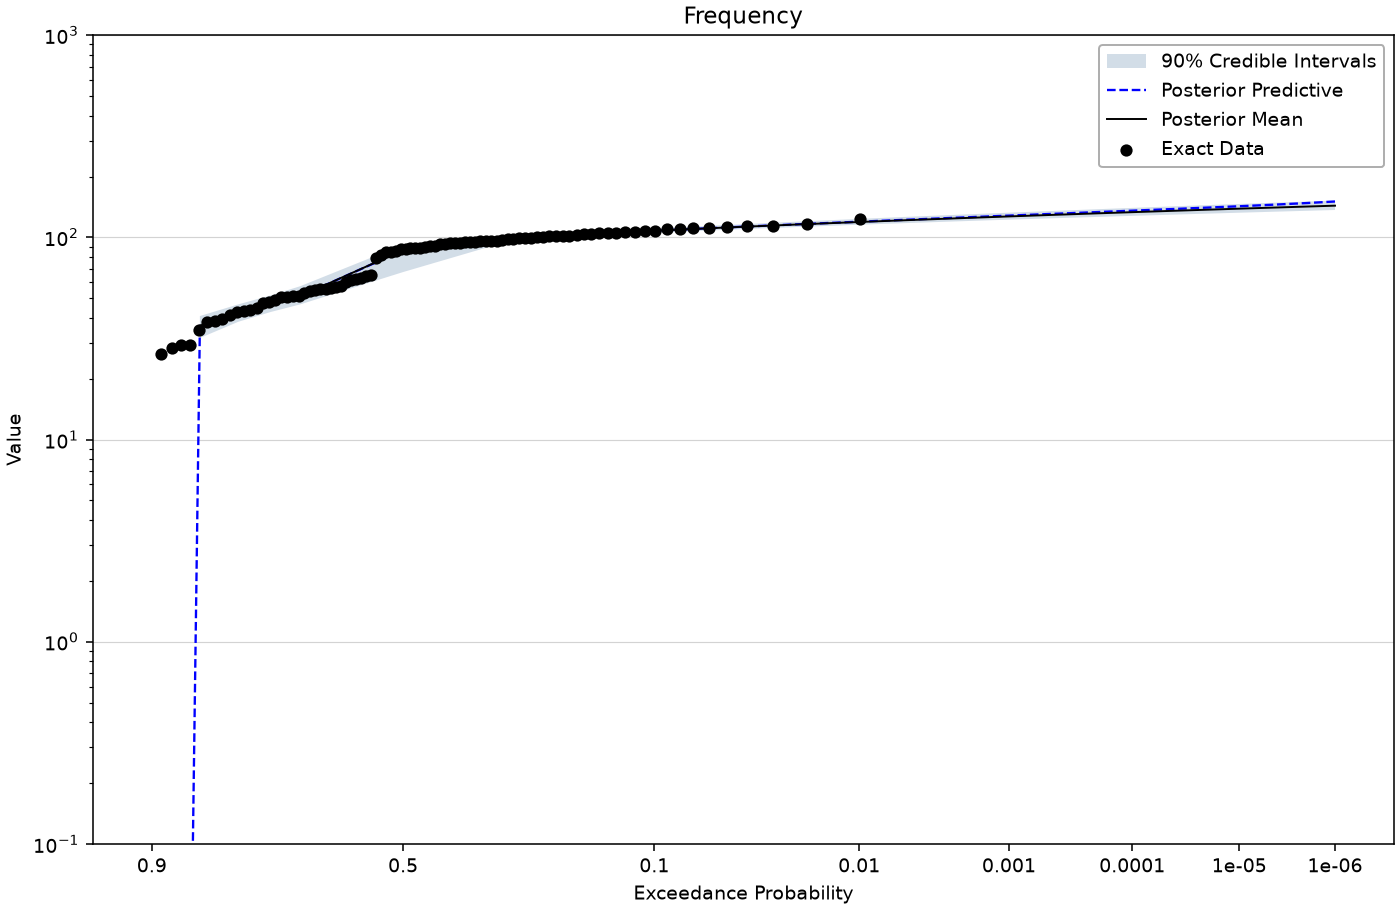

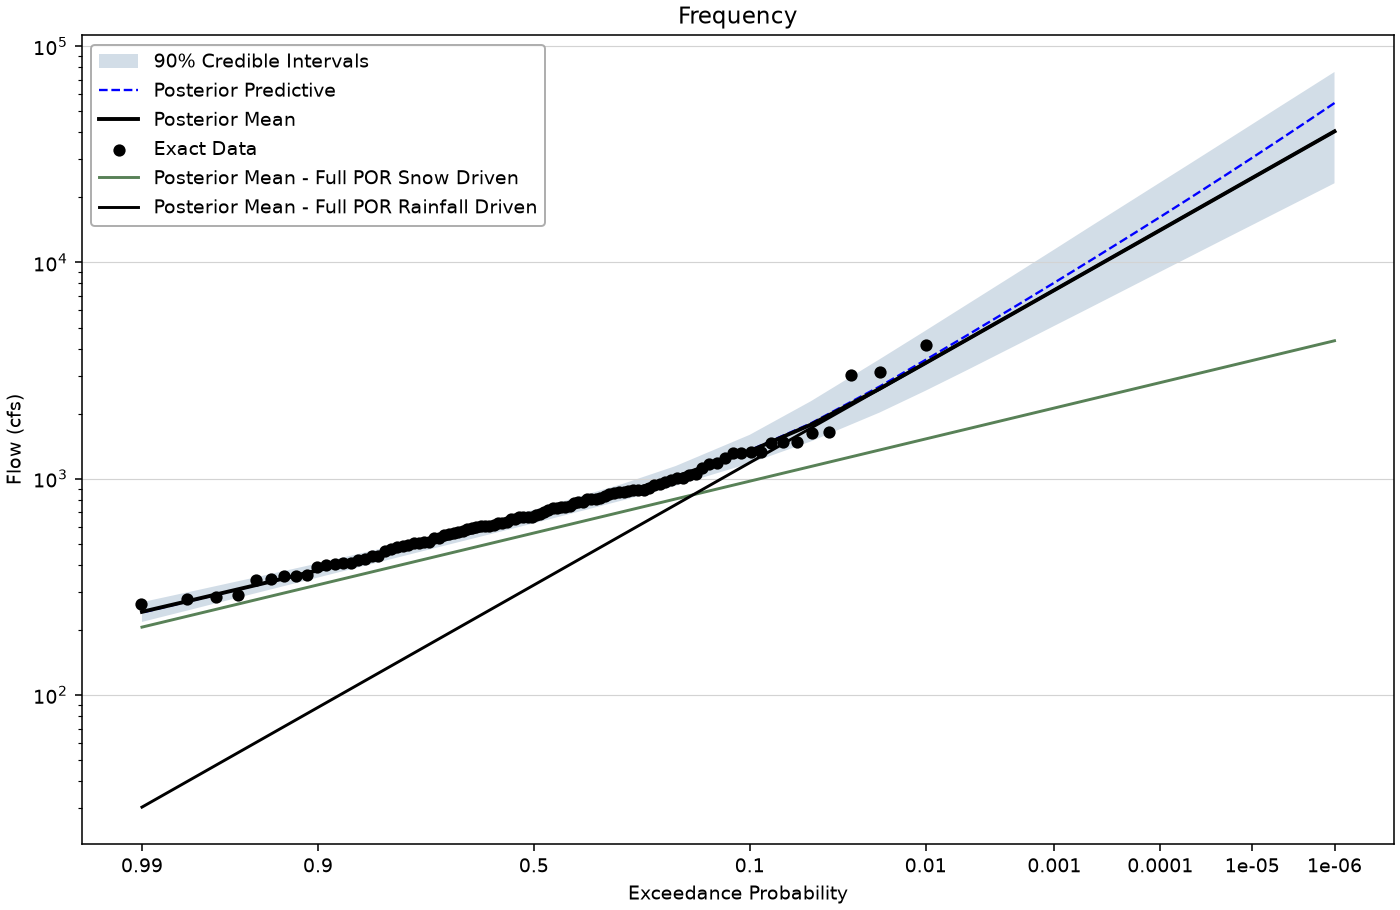

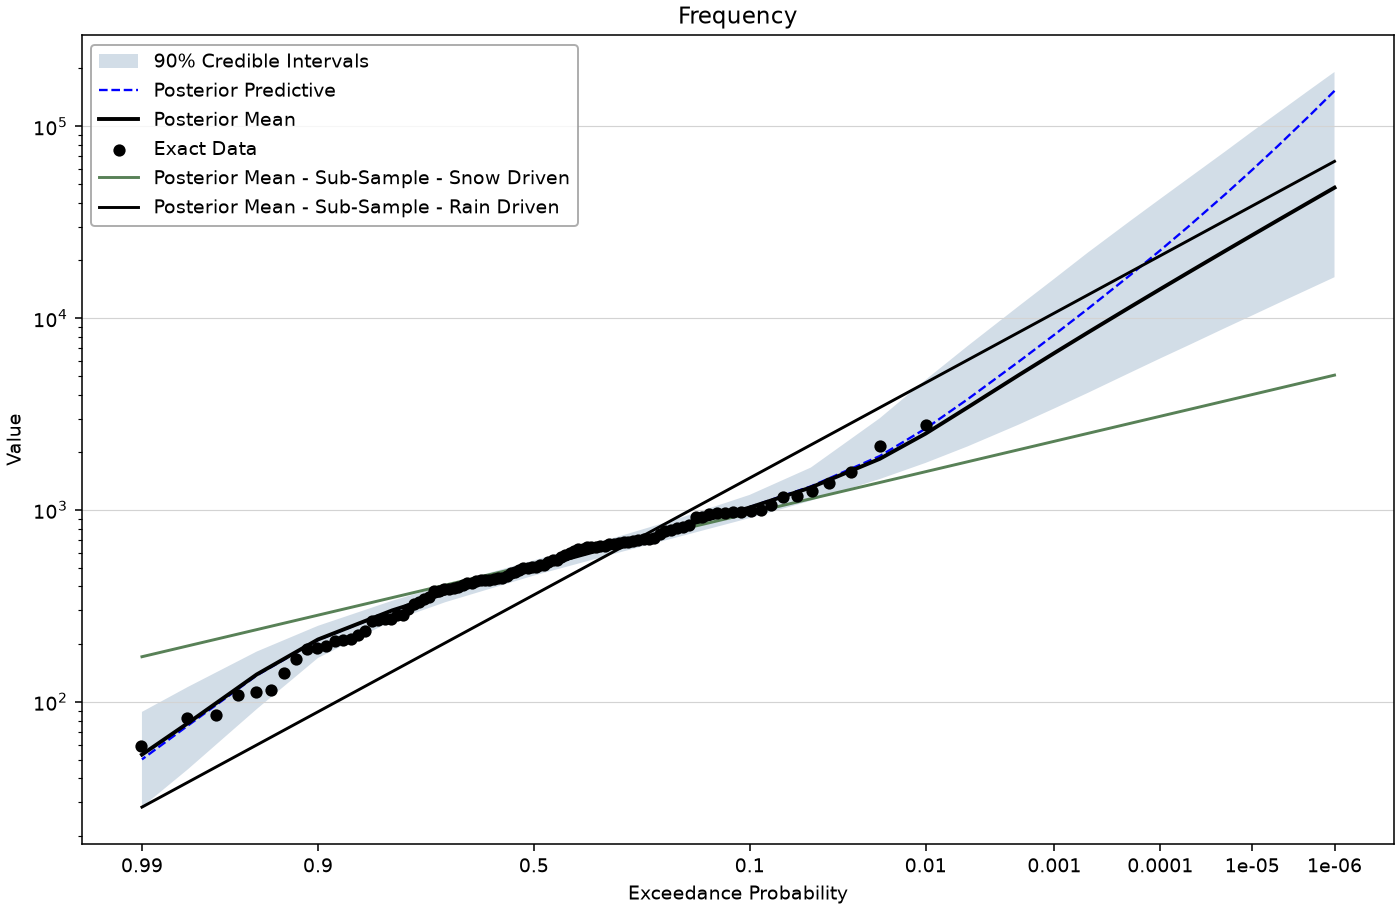

In [10]:
top_level_names = [name for name, *_ in [
    ("USC00040741 - Point Process",),
    ("USC00040741 - GEV",),
    ("USC00040741 - Seasonal Point Process",),
    ("Mixture Distribution - 2 Normals",),
    ("Mixture Distribution - 2 Normals - Zero-Inflated",),
    ("Competing Flood Types",),
    ("Mixture of Flood Types",)]]
display(pd.DataFrame([{"Case": name, "Class": str(analyses[name].GetType().Name),
                       "Run seconds": timings[name]} for name in top_level_names]))
# Independent mixture aggregation from the freshly fitted Normal coordinates.
# A zero-inflated component is a Normal conditional on being positive; its
# separate point mass at zero is retained exactly.
for name, _, inflated in mixture_cases:
    mixture = analyses[name].GetPointEstimateDistribution()
    zero_weight = float(mixture.ZeroWeight) if inflated else 0.0
    for x in (0.0, 35.0, 75.0, 120.0):
        expected = zero_weight if inflated else 0.0
        for weight, normal in zip(mixture.Weights, mixture.Distributions):
            mu, sigma = float(normal.Mu), float(normal.Sigma)
            cdf_x = .5 * (1.0 + erf((x - mu) / (sigma * sqrt(2.0))))
            cdf_zero = .5 * (1.0 + erf(-mu / (sigma * sqrt(2.0))))
            component_cdf = ((cdf_x - cdf_zero) / (1.0 - cdf_zero)
                             if inflated and x > 0.0 else 0.0 if inflated else cdf_x)
            expected += float(weight) * component_cdf
        assert isclose(float(mixture.CDF(x)), expected, rel_tol=1e-10, abs_tol=1e-10)
# The two flood-process aggregations obey different analytical identities
# for independent components at every test flow.
for x in (10.0, 50.0, 150.0):
    snow = float(analyses["Full POR Snow Driven"].GetPointEstimateDistribution().CDF(x))
    rain = float(analyses["Full POR Rainfall Driven"].GetPointEstimateDistribution().CDF(x))
    competing = analyses["Competing Flood Types"].GetPointEstimateDistribution()
    assert isclose(float(competing.CDF(x)), snow * rain, rel_tol=1e-10, abs_tol=1e-10)
    snow_sub = float(analyses["Sub-Sample - Snow Driven"].GetPointEstimateDistribution().CDF(x))
    rain_sub = float(analyses["Sub-Sample - Rain Driven"].GetPointEstimateDistribution().CDF(x))
    flood_mixture = analyses["Mixture of Flood Types"].GetPointEstimateDistribution()
    assert isclose(float(flood_mixture.CDF(x)), .75 * snow_sub + .25 * rain_sub,
                   rel_tol=1e-10, abs_tol=1e-10)
diagnostics = []
for name in [*top_level_names[:5], *(child_name for child_name, _ in child_specs)]:
    result = analyses[name].BayesianAnalysis.Results
    for i, parameter in enumerate(result.ParameterResults):
        stats = parameter.SummaryStatistics
        diagnostics.append({"Case": name, "Parameter index": i,
                            "R-hat": float(stats.Rhat), "ESS": float(stats.ESS)})
display(pd.DataFrame(diagnostics))
specs, contexts = {}, {}
for name in top_level_names:
    source = pot_raw if name.startswith("USC") else mix_raw if name.startswith("Mixture Distribution") else flood_raw
    input_name = (
        pot_inputs[0] if "Point Process" in name else
        pot_inputs[1] if name == "USC00040741 - GEV" else
        mixture_inputs[1] if name.endswith("Zero-Inflated") else
        mixture_inputs[0] if name.startswith("Mixture Distribution") else
        "Full POR - Annual Max Series" if name == "Competing Flood Types" else
        "AMS Mixture of Flood Types")
    if name in ("Competing Flood Types", "Mixture of Flood Types"):
        dependencies = {}
        for child_name, _ in next(item[2] for item in composite_specs if item[0] == name):
            child_input = next(item[1] for item in child_specs if item[0] == child_name)
            dependencies[child_name] = plot_context(
                analyses[child_name], models[child_name], name=child_name, raw=flood_raw,
                frame=frames[child_input], metadata=flood_raw["inputs"][child_input]["metadata"])
    else:
        dependencies = {}
    context = plot_context(analyses[name], models.get(name), name=name, raw=source,
                           frame=frames.get(input_name), metadata=source["inputs"][input_name]["metadata"],
                           dependencies=dependencies)
    contexts[name] = context
    specs[name] = plots(context)
    show(specs[name]["frequency"])

**Adapt this example:** preserve dates and exposure when moving from POT to
AMS, keep zeros as a point mass, and explain whether flood mechanisms compete
within a year or are sampled as a mixture.